In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import distance_transform_edt

In [3]:
dist_maps = np.load("dist_in.npy")
goal_map = np.load("goal.npy")
mask_maps = np.load("mask.npy")
output_maps = np.load("output.npy")

In [4]:
directions = np.array([[0, 5], [5, 0], [0, -5], [-5, 0], [5, 5], [5, -5], [-5, 5], [-5, -5]])

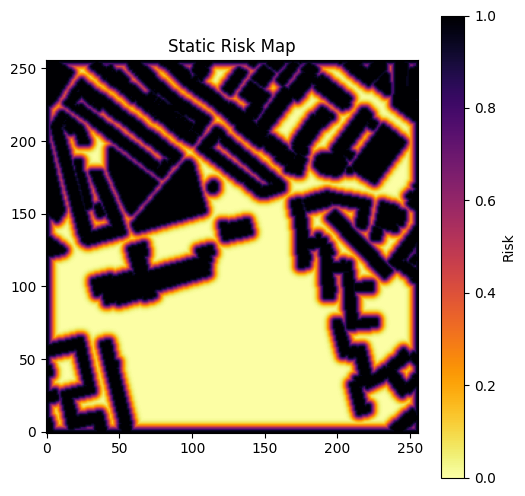

In [16]:
dist_map = dist_maps[20]
sigma = 3.0

risk_map = np.exp(-(dist_map ** 2)/(2 * sigma ** 2))
risk_map = (risk_map - risk_map.min()) / (risk_map.max() - risk_map.min())

plt.figure(figsize=(6, 6))
plt.imshow(risk_map, cmap='inferno_r', origin='lower')
plt.colorbar(label='Risk')
plt.title('Static Risk Map')
plt.show()
plt.close()

In [19]:
mask_map = mask_maps[80]

free_cells = np.argwhere(mask_map == 1)
risk_values = risk_map[free_cells[:, 0], free_cells[:, 1]]

start_position = free_cells[np.argmin(risk_values)]

print("Start Position:", start_position)

Start Position: [ 55 124]


Velocity: [-5  0]


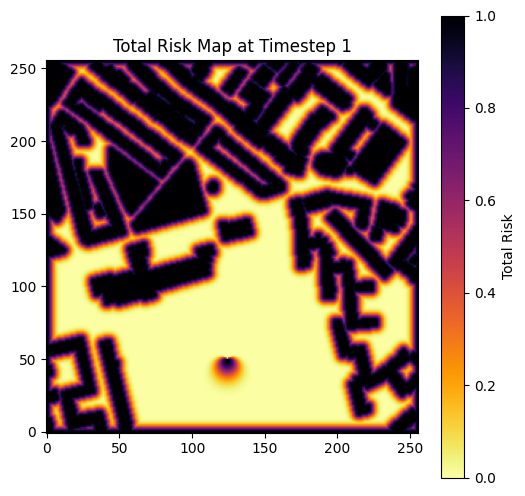

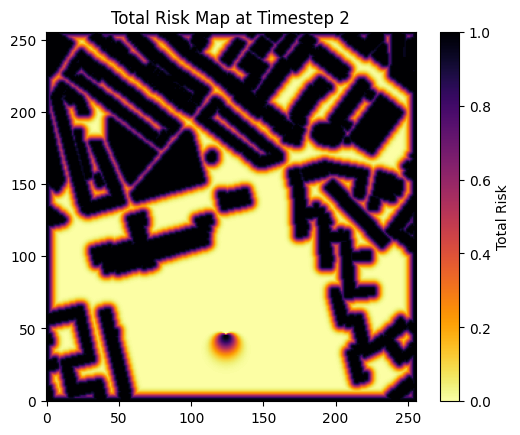

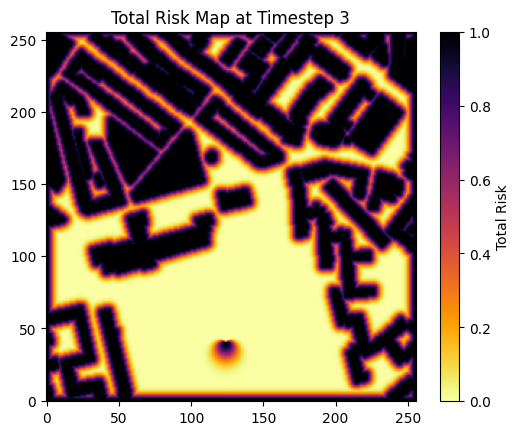

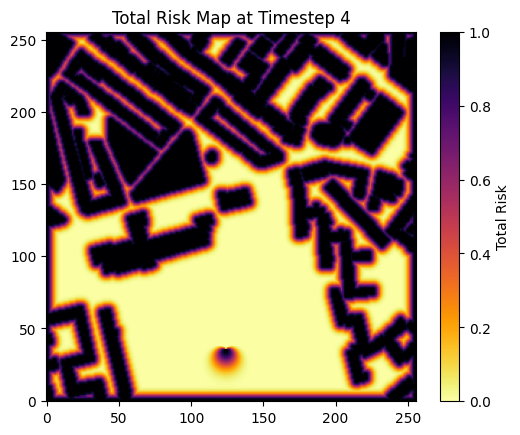

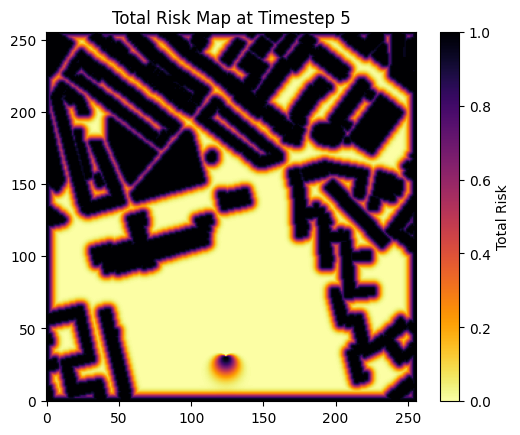

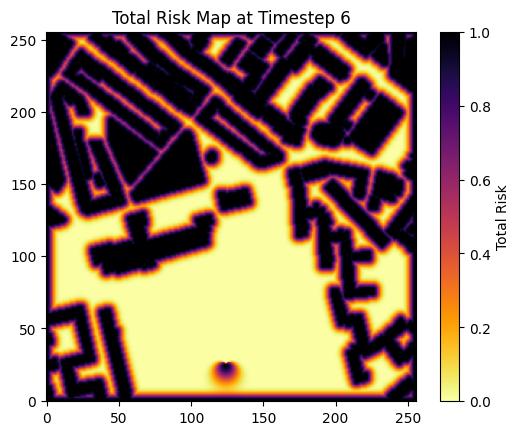

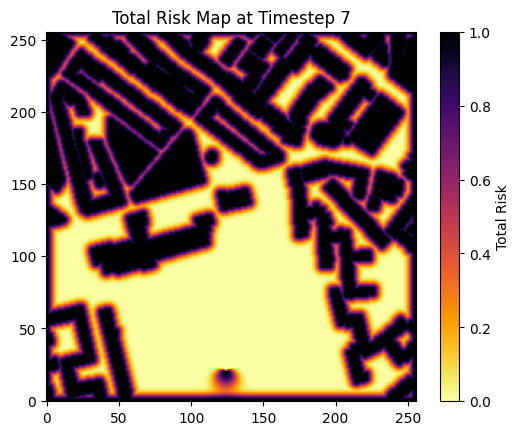

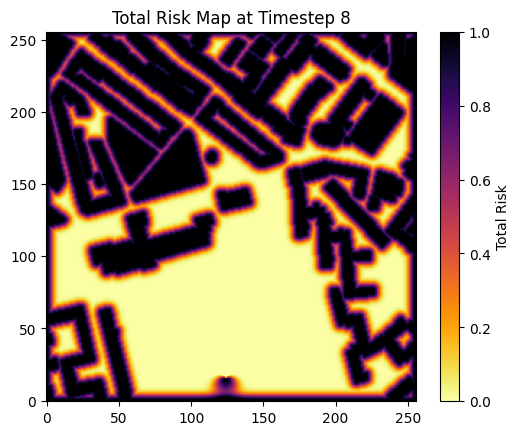

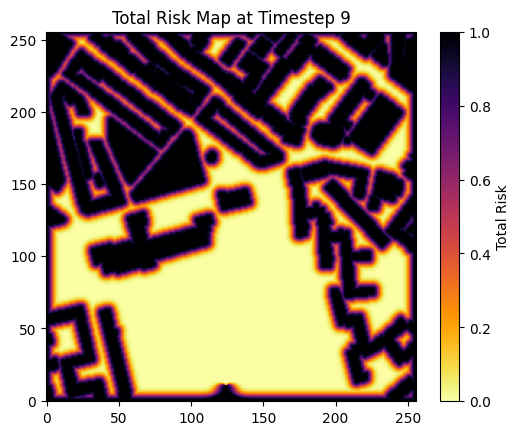

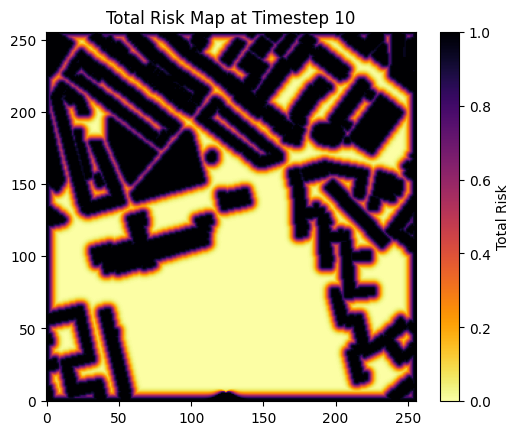

In [20]:
H, W = dist_map.shape
obstacle_position = np.array(start_position)
velocity = directions[np.random.choice(len(directions))]
sigma_dynamic = 4.0
alpha_dynamic = 1.0
timesteps = 10
print("Velocity:", velocity)

plt.figure(figsize=(6, 6))
for t in range(timesteps):
    obstacle_position += velocity
    obstacle_position = np.clip(obstacle_position, [0, 0], [H-1, W-1])

    obstacle_grid = np.zeros((H, W))
    obstacle_grid[obstacle_position[0], obstacle_position[1]] = 1

    dynamic_distance = distance_transform_edt(1 - obstacle_grid)

    x_coordinates, y_coordinates = np.meshgrid(np.arange(W), np.arange(H), indexing='ij')
    dx = x_coordinates - obstacle_position[0]
    dy = y_coordinates - obstacle_position[1]

    velocity_norm = np.linalg.norm(velocity) + 1e-6
    d_norm = np.sqrt(dx**2 + dy**2) + 1e-6
    cos_theta = (dx * velocity[0] + dy * velocity[1]) / (velocity_norm * d_norm)

    w = 1 + alpha_dynamic * cos_theta
    directional_distance = dynamic_distance / w

    dynamic_risk = np.exp(-(directional_distance ** 2)/(2 * sigma_dynamic ** 2))
    dynamic_risk = (dynamic_risk - dynamic_risk.min()) / (dynamic_risk.max() - dynamic_risk.min())

    total_risk = risk_map + dynamic_risk
    total_risk = np.clip(total_risk, 0, 1)

    plt.imshow(total_risk, cmap='inferno_r', origin='lower')
    plt.colorbar(label='Total Risk')
    plt.title(f'Total Risk Map at Timestep {t+1}')
    plt.show()
    plt.close()
